# 260410-1: PyTorch로 Linear Classifier 구현하기

이번 실습에서는 PyTorch를 사용하여 CIFAR-10 데이터셋에 대한 **Linear Classifier**를 직접 구현합니다.

## 학습 목표
- PyTorch의 핵심 모듈(`nn`, `optim`, `DataLoader`)의 역할 이해하기
- **Softmax** 함수와 **Cross-Entropy Loss**를 직접 구현하고 이해하기
- PyTorch의 **SGD 학습 루프**를 직접 작성하기
- 학습 결과를 **시각화**하여 분석하기

## 구성
1. PyTorch 핵심 모듈 소개 및 환경 설정
2. CIFAR-10 데이터 로딩 및 시각화
3. Softmax와 Cross-Entropy Loss 직접 구현
4. Linear Classifier 모델 정의
5. SGD 학습 루프 작성 + Gradient 확인
6. 학습 결과 평가
7. (Bonus) Learning Rate에 따른 결과 비교

### Recap: 오전 강의 핵심

> **Foundations of Deep Learning** — Linear Models

| 개념 | 핵심 |
|------|------|
| **Linear Model** | $\text{scores} = Wx + b$ — 입력에 가중치를 곱해 클래스별 점수 계산 |
| **Softmax** | raw score → 확률 분포로 변환 ($\sum p_i = 1$) |
| **Cross-Entropy Loss** | 정답 클래스의 확률을 최대화하는 손실 함수 |
| **Train / Val / Test** | Train으로 학습, Val로 하이퍼파라미터 선택, Test로 최종 평가 |
| **Capacity** | 모델이 표현할 수 있는 함수의 복잡도 — 너무 작으면 underfitting, 너무 크면 overfitting |

이번 실습에서는 위 개념들을 **PyTorch로 직접 구현**하며 체험합니다.

In [1]:
# Colab environment setup & dependency installation
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Mount Google Drive (optional - for saving results)
    # from google.colab import drive
    # drive.mount('/content/drive')

    # GPU check
    import subprocess
    gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if gpu_info.returncode == 0:
        print('GPU available:')
        print(gpu_info.stdout.split('\n')[8])  # GPU name line
    else:
        print('No GPU detected. Go to Runtime > Change runtime type > GPU')

    # Install additional libraries (torch, torchvision are pre-installed in Colab)
    !pip install -q scikit-learn matplotlib

    print('\nColab setup complete!')
else:
    print('Running locally (not Colab)')

print(f'Python: {sys.version.split()[0]}')

GPU available:
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |

Colab setup complete!
Python: 3.12.13


## 1. PyTorch 핵심 모듈 소개 및 환경 설정

PyTorch에서 딥러닝 학습에 사용하는 핵심 모듈들은 다음과 같습니다:

```
┌──────────────────────────────────────────────────────────────────┐
│                        PyTorch 학습 파이프라인                      │
│                                                                  │
│   [데이터]              [모델]              [최적화]                │
│                                                                  │
│   torchvision.datasets  torch.nn (nn)       torch.optim          │
│     → 데이터셋 로딩       → 레이어, 모델 정의    → SGD, Adam 등       │
│                                                                  │
│   torchvision.transforms                                         │
│     → 전처리 (정규화 등)                                            │
│                                                                  │
│   DataLoader                                                     │
│     → 배치 생성, 셔플                                               │
└──────────────────────────────────────────────────────────────────┘
```

| 모듈 | 역할 | 예시 |
|------|------|------|
| `torch.nn` | 신경망 레이어, 손실 함수 정의 | `nn.Linear`, `nn.CrossEntropyLoss` |
| `torch.optim` | 파라미터 최적화 알고리즘 | `optim.SGD`, `optim.Adam` |
| `DataLoader` | 데이터를 미니배치로 나눠서 공급 | 배치 크기, 셔플, 병렬 로딩 |
| `torchvision` | 이미지 데이터셋 & 전처리 도구 | CIFAR-10, transforms |

> **참고**: 이미지 augmentation 라이브러리로는 `torchvision.transforms` 외에도 **[Albumentations](https://albumentations.ai/)**가 실무에서 많이 사용됩니다. 더 다양한 변환과 빠른 속도를 제공합니다.

### Device와 Generator

**`torch.device`**: 연산을 수행할 하드웨어를 지정합니다.
- `'cpu'`: CPU에서 연산
- `'cuda'`: NVIDIA GPU에서 연산 (훨씬 빠름)

### 재현성(Reproducibility) 보장: 두 가지 방법

난수 시드를 고정하면 매번 동일한 결과를 얻을 수 있습니다. PyTorch에서는 두 가지 방법을 제공합니다:

| 방법 | 사용법 | 범위 |
|------|--------|------|
| `torch.manual_seed(42)` | **전역(global)** 시드 설정 | 이후 모든 랜덤 연산에 영향 |
| `torch.Generator().manual_seed(42)` | **지역(local)** 시드 생성기 | 특정 연산에만 전달 가능 |

둘 다 자주 사용됩니다. `manual_seed`는 간편하고, `Generator`는 서로 다른 연산에 독립적인 시드를 줄 수 있어 더 세밀한 제어가 가능합니다.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Method 1: Global seed (torch.manual_seed)
torch.manual_seed(42)
print(f'\n[Global seed] torch.manual_seed(42)')
print(f'  random values: {torch.randint(100, (3,)).tolist()}')
torch.manual_seed(42)  # reset -> same result
print(f'  random values: {torch.randint(100, (3,)).tolist()}  (same!)')

# Method 2: Local Generator
g = torch.Generator().manual_seed(42)
print(f'\n[Local generator] torch.Generator().manual_seed(42)')
print(f'  random values: {torch.randint(100, (3,), generator=g).tolist()}')
g = torch.Generator().manual_seed(42)
print(f'  random values: {torch.randint(100, (3,), generator=g).tolist()}  (same!)')

Using device: cuda

[Global seed] torch.manual_seed(42)
  random values: [42, 67, 76]
  random values: [42, 67, 76]  (same!)

[Local generator] torch.Generator().manual_seed(42)
  random values: [42, 67, 76]
  random values: [42, 67, 76]  (same!)


## 2. CIFAR-10 데이터 로딩 및 시각화

### 이미지 텐서의 차원 순서: C × H × W

이미지를 다루는 라이브러리마다 차원 순서(convention)가 다릅니다:

```
PIL / NumPy / matplotlib:    (H, W, C)  →  (높이, 너비, 채널)
PyTorch / torchvision:       (C, H, W)  →  (채널, 높이, 너비)
```

예를 들어 CIFAR-10의 32×32 컬러 이미지는:
- PIL로 읽으면: `(32, 32, 3)` — 마지막이 RGB 채널
- `transforms.ToTensor()`를 거치면: `(3, 32, 32)` — 첫 번째가 채널

> **왜 PyTorch는 (C, H, W)를 쓸까?**
> Convolution 연산에서 채널 축이 앞에 있어야 효율적으로 계산할 수 있기 때문입니다.

### Dataset과 DataLoader

```
┌─────────────┐     ┌──────────────┐     ┌──────────────────────┐
│   Dataset    │ ──→ │  DataLoader  │ ──→ │  미니배치 (batch)      │
│  (전체 데이터) │     │ (배치 생성기)  │     │  images: (256,3,32,32)│
│              │     │              │     │  labels: (256,)       │
│  __len__()   │     │  batch_size  │     └──────────────────────┘
│  __getitem__()│    │  shuffle     │
│  transform   │     │  num_workers │
└─────────────┘     │  collate_fn  │
                    └──────────────┘
```

- **Dataset**: `__getitem__(index)`로 하나의 샘플을 반환합니다. `transform`이 여기서 적용됩니다.
- **DataLoader**: Dataset에서 샘플을 꺼내 배치로 묶어줍니다.
  - `batch_size`: 한 배치에 몇 개의 샘플을 넣을지
  - `shuffle`: 에폭마다 순서를 섞을지 (train은 True, val/test는 False)
  - `collate_fn`: 개별 샘플들을 하나의 배치 텐서로 합치는 함수 (기본값이 대부분 충분합니다)
  - `num_workers`: 데이터 로딩을 병렬로 처리할 프로세스 수

In [3]:
# CIFAR-10 데이터 로딩
# transforms.ToTensor(): PIL Image (H,W,C) [0,255] → Tensor (C,H,W) [0.0,1.0]
# transforms.Normalize(): 각 채널별 (평균, 표준편차)로 정규화 → 평균 0, 분산 1 근처로
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Train/Validation 분할 (Generator로 재현성 보장)
train_set, val_set = torch.utils.data.random_split(
    trainset, [45000, 5000],
    generator=torch.Generator().manual_seed(42)
)

# DataLoader 생성
train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)
test_loader = DataLoader(testset, batch_size=256, shuffle=False)

CLASSES = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print(f'Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(testset)}')

# 차원 순서 확인
sample_img, sample_label = trainset[0]
print(f'\nSingle image tensor shape: {sample_img.shape}  ->  (C, H, W) = (Channel, Height, Width)')
print(f'Class: {CLASSES[sample_label]}')

100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


Train: 45000, Val: 5000, Test: 10000

Single image tensor shape: torch.Size([3, 32, 32])  ->  (C, H, W) = (Channel, Height, Width)
Class: frog


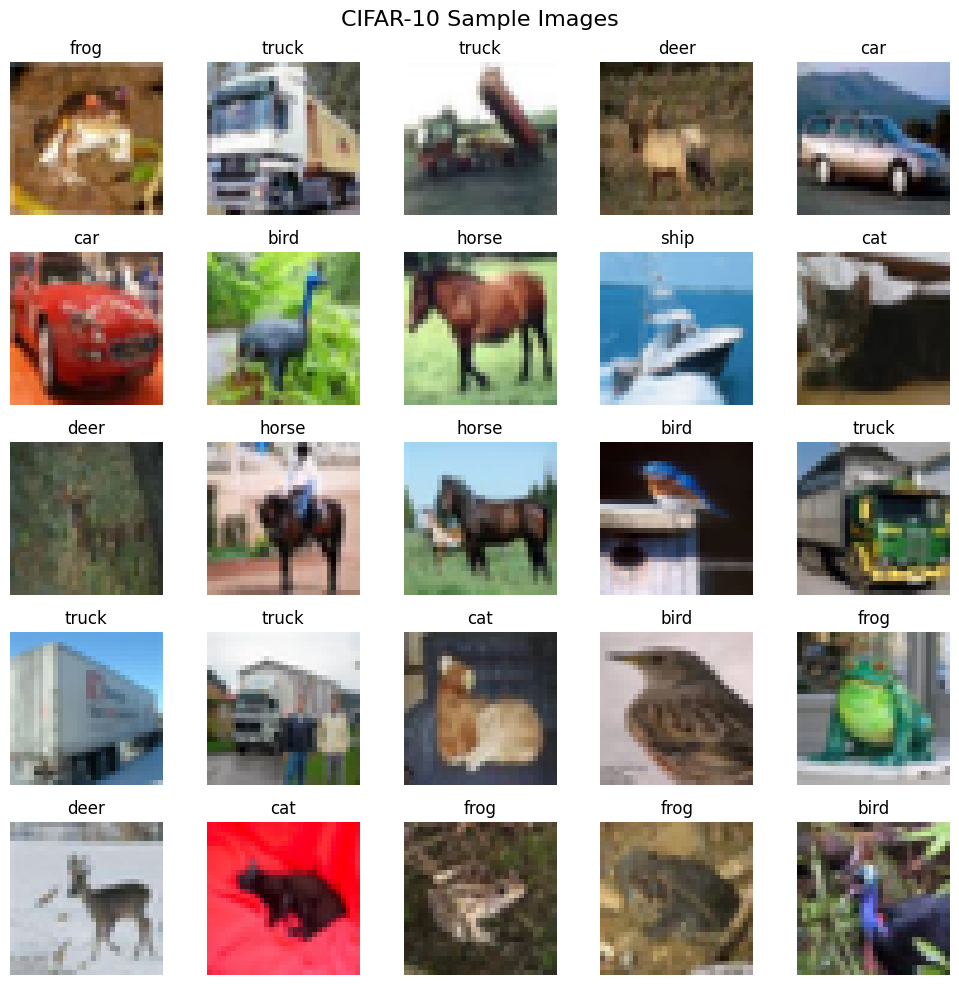

In [4]:
 # 샘플 이미지 시각화
def imshow(img_tensor):
    """정규화된 (C,H,W) 텐서를 matplotlib용 (H,W,C)로 변환"""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = img_tensor * std + mean  # 역정규화
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).numpy()  # (C,H,W) → (H,W,C) for matplotlib

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i in range(25):
    img, label = trainset[i]
    ax = axes[i // 5][i % 5]
    ax.imshow(imshow(img))
    ax.set_title(CLASSES[label])
    ax.axis('off')
plt.suptitle('CIFAR-10 Sample Images', fontsize=16)
plt.tight_layout()
plt.show()

## 3. Softmax와 Cross-Entropy Loss 직접 구현하기

### Softmax 함수
모델이 출력한 raw score (logit)를 확률 분포로 변환하는 함수입니다.

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{C} e^{z_j}}$$

### 수치적 안정성 (Numerical Stability)
$e^{z_i}$는 $z_i$가 큰 값일 때 **overflow**가 발생합니다. 이를 방지하기 위해 최대값을 빼줍니다 (**log-sum-exp trick**):

$$\text{softmax}(z_i) = \frac{e^{z_i - m}}{\sum_{j=1}^{C} e^{z_j - m}}, \quad m = \max_j z_j$$

최대값을 빼주어도 수학적으로 결과는 동일하지만, overflow를 방지할 수 있습니다.
아래에서 실제로 어떤 차이가 나는지 확인해봅니다.

In [5]:
def my_softmax(logits):
    """
    Softmax 함수를 직접 구현하세요.
    수치적 안정성을 위해 log-sum-exp trick을 사용하세요.

    Args:
        logits: (N, C) 크기의 텐서 (raw scores)
    Returns:
        probs: (N, C) 크기의 텐서 (확률값, 각 행의 합 = 1)

    Hint: m = torch.max(logits, dim=1, keepdim=True).values
          먼저 logits에서 m을 빼준 뒤 exp를 계산하세요.
    """

    ############################################################################
    # TODO 1: 여기에 구현하세요 (~3줄)                                            #
    ############################################################################
    m = torch.max(logits, dim=1, keepdim=True).values
    exp_logits = torch.exp(logits - m)
    probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################
    return probs

In [6]:
# 검증: torch.softmax과 비교
test_logits = torch.randn(4, 10)

my_result = my_softmax(test_logits)
torch_result = torch.softmax(test_logits, dim=1)

print(f'Max difference: {(my_result - torch_result).abs().max().item():.2e}')
print(f'Row sums (should all be 1): {my_result.sum(dim=1)}')
# 예상 출력: max difference < 1e-6

Max difference: 5.96e-08
Row sums (should all be 1): tensor([1.0000, 1.0000, 1.0000, 1.0000])


In [7]:
# 수치적 안정성 데모: 큰 값에서 naive softmax vs stable softmax
logits_small = torch.tensor([[1.0, 2.0, 3.0]])     # 작은 값 → 문제 없음
logits_large = torch.tensor([[1000.0, 1001.0, 1002.0]])  # 큰 값 → overflow!

# Naive softmax (max를 빼지 않음)
def naive_softmax(z):
    exp_z = torch.exp(z)
    return exp_z / exp_z.sum(dim=1, keepdim=True)

# Stable softmax (max를 빼줌)
def stable_softmax(z):
    m = z.max(dim=1, keepdim=True).values
    exp_z = torch.exp(z - m)
    return exp_z / exp_z.sum(dim=1, keepdim=True)

print("=== Small values (logits = [1, 2, 3]) ===")
print(f"Naive:  {naive_softmax(logits_small)}")
print(f"Stable: {stable_softmax(logits_small)}")

print("\n=== Large values (logits = [1000, 1001, 1002]) ===")
print(f"Naive:  {naive_softmax(logits_large)}")   # may produce nan!
print(f"Stable: {stable_softmax(logits_large)}")   # safe output
print("\n-> Naive method produces inf/nan with large values, stable method is safe!")

=== Small values (logits = [1, 2, 3]) ===
Naive:  tensor([[0.0900, 0.2447, 0.6652]])
Stable: tensor([[0.0900, 0.2447, 0.6652]])

=== Large values (logits = [1000, 1001, 1002]) ===
Naive:  tensor([[nan, nan, nan]])
Stable: tensor([[0.0900, 0.2447, 0.6652]])

-> Naive method produces inf/nan with large values, stable method is safe!


### Cross-Entropy Loss
정답 클래스의 예측 확률에 음의 로그를 취한 것입니다:

$$L = -\frac{1}{N} \sum_{i=1}^{N} \log p(y_i | x_i) = -\frac{1}{N} \sum_{i=1}^{N} \left( z_{y_i} - \log \sum_j e^{z_j} \right)$$

In [8]:
def my_cross_entropy_loss(logits, targets):
    """
    Cross-Entropy Loss를 직접 구현하세요.

    Args:
        logits: (N, C) 크기의 텐서 (모델의 raw output)
        targets: (N,) 크기의 텐서 (정답 클래스 인덱스, 0 ~ C-1)
    Returns:
        loss: 스칼라 값 (평균 cross-entropy loss)

    Hint: N개 샘플에 대해 정답 클래스의 logit을 뽑으려면
          logits[range(N), targets] 를 사용하세요.
    """
    ############################################################################
    # TODO 2: 여기에 구현하세요 (~5줄)                                            #
    ############################################################################
    N = logits.shape[0]
    m = torch.max(logits, dim=1, keepdim=True).values
    log_sum_exp = m.squeeze() + torch.log(torch.sum(torch.exp(logits - m), dim=1))
    correct_logits = logits[range(N), targets]
    loss = torch.mean(log_sum_exp - correct_logits)
    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################
    return loss

In [9]:
# 검증: nn.CrossEntropyLoss와 비교
test_logits = torch.randn(4, 10)
test_targets = torch.tensor([3, 0, 7, 1])

my_loss = my_cross_entropy_loss(test_logits, test_targets)
torch_loss = nn.CrossEntropyLoss()(test_logits, test_targets)

print(f'My loss:    {my_loss.item():.6f}')
print(f'Torch loss: {torch_loss.item():.6f}')
print(f'Difference: {abs(my_loss.item() - torch_loss.item()):.2e}')
# 예상: difference < 1e-5

My loss:    1.976053
Torch loss: 1.976053
Difference: 0.00e+00


## 4. Linear Classifier 모델 정의

Linear Classifier는 입력 이미지를 1차원 벡터로 펼친 뒤, 하나의 선형 변환으로 각 클래스에 대한 점수(score)를 출력합니다.

$$\text{scores} = Wx + b$$

- 입력: $x \in \mathbb{R}^{3072}$ (32 × 32 × 3 = 3072)
- 가중치: $W \in \mathbb{R}^{10 \times 3072}$, 편향: $b \in \mathbb{R}^{10}$
- 출력: 10개 클래스에 대한 점수

In [10]:
class LinearClassifier(nn.Module):
    def __init__(self, input_dim=3*32*32, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()           # (N, 3, 32, 32) → (N, 3072)
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        scores = self.fc(x)
        return scores

model = LinearClassifier().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

LinearClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=3072, out_features=10, bias=True)
)

Total parameters: 30,730


### 가중치 초기화 (Weight Initialization)

모델의 초기 가중치는 학습의 출발점을 결정합니다. 초기화 방법에 따라 학습 속도와 성능이 크게 달라질 수 있습니다.

| 초기화 방법 | 설명 | 적합한 경우 |
|------------|------|------------|
| **Zeros** | 모든 가중치를 0으로 | 사용 금지! (모든 뉴런이 동일하게 업데이트됨) |
| **Random Normal** | 정규분포 N(0, σ²)에서 샘플링 | 간단한 실험용 |
| **Xavier (Glorot)** | N(0, 2/(n_in+n_out)) | Sigmoid, Tanh 활성화 함수 |
| **Kaiming (He)** | N(0, 2/n_in) | **ReLU** 활성화 함수 (가장 많이 사용) |

> `nn.Linear`는 기본적으로 **Kaiming Uniform** 초기화를 사용합니다.

아래에서 각 초기화 방법으로 가중치를 설정하고, 실제 값의 분포를 확인해봅니다.

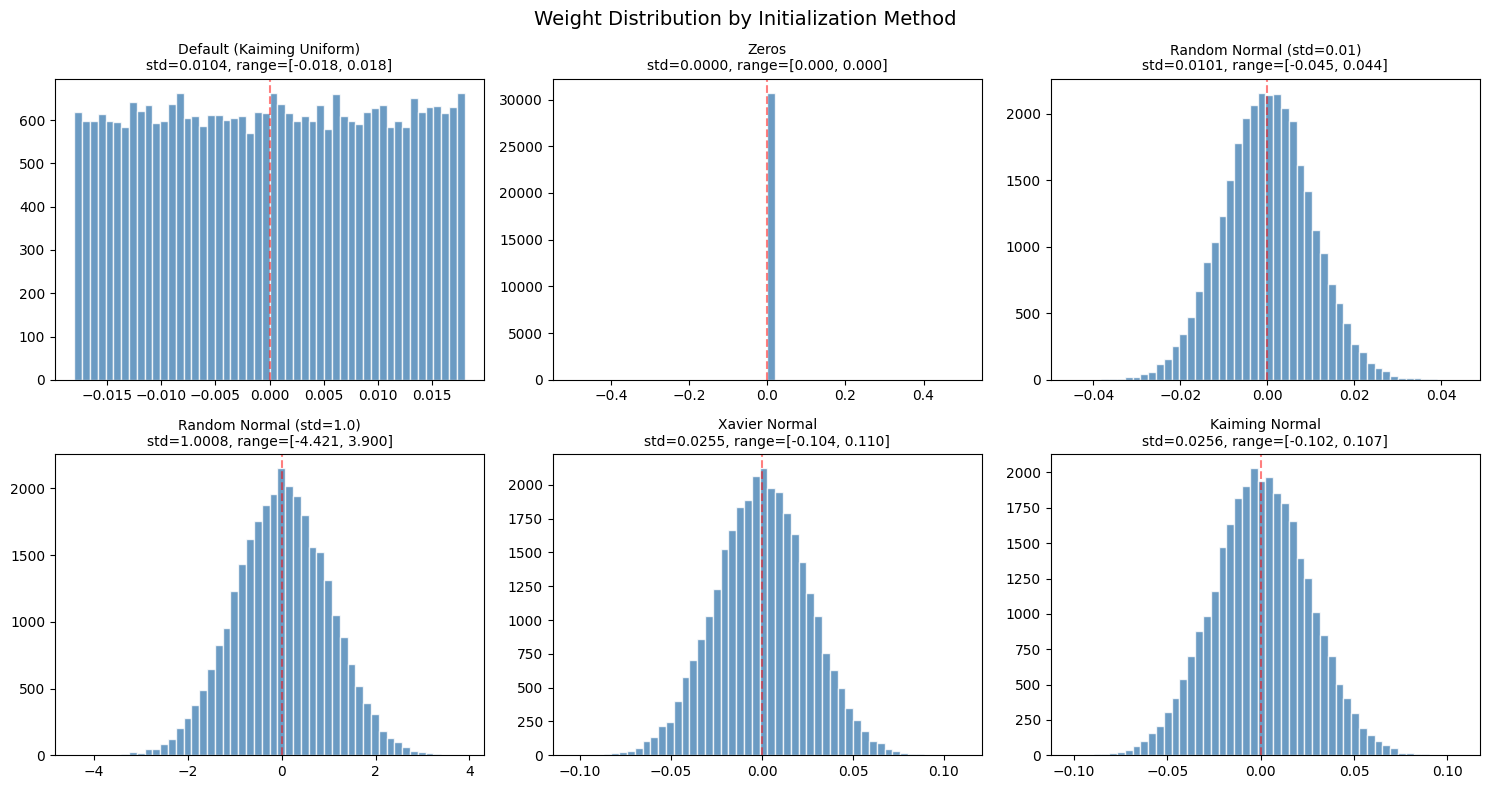

In [11]:
# 다양한 초기화 방법 비교
import torch.nn.init as init

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

init_methods = {
    'Default (Kaiming Uniform)': None,
    'Zeros': lambda w: init.zeros_(w),
    'Random Normal (std=0.01)': lambda w: init.normal_(w, mean=0, std=0.01),
    'Random Normal (std=1.0)': lambda w: init.normal_(w, mean=0, std=1.0),
    'Xavier Normal': lambda w: init.xavier_normal_(w),
    'Kaiming Normal': lambda w: init.kaiming_normal_(w, mode='fan_in', nonlinearity='relu'),
}

for ax, (name, init_fn) in zip(axes.flatten(), init_methods.items()):
    model_tmp = LinearClassifier()
    if init_fn is not None:
        init_fn(model_tmp.fc.weight)

    w = model_tmp.fc.weight.data.flatten().numpy()
    ax.hist(w, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{name}\nstd={w.std():.4f}, range=[{w.min():.3f}, {w.max():.3f}]', fontsize=10)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Weight Distribution by Initialization Method', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# 초기화에 따른 모델 초기 출력 비교
# 같은 입력에 대해 초기화 방식에 따라 출력(score)이 얼마나 다른지 확인
sample_batch, _ = next(iter(train_loader))
sample_batch = sample_batch.to(device)

print("Output scores (10 classes) for first sample by initialization method:")
print("=" * 70)

for name, init_fn in init_methods.items():
    model_tmp = LinearClassifier().to(device)
    if init_fn is not None:
        with torch.no_grad():
            init_fn(model_tmp.fc.weight)

    with torch.no_grad():
        scores = model_tmp(sample_batch[:1])  # 첫 번째 이미지만

    probs = torch.softmax(scores, dim=1)
    print(f"{name:30s} | score range: [{scores.min():.2f}, {scores.max():.2f}] | "
          f"max prob: {probs.max():.4f}")

print("\n-> Good initialization: initial max prob should be close to 1/10 = 0.1 (uniform prediction)")
print("-> Too large std: overconfident on one class. Zero: all classes identical.")

Output scores (10 classes) for first sample by initialization method:
Default (Kaiming Uniform)      | score range: [-1.43, 1.25] | max prob: 0.2868
Zeros                          | score range: [-0.02, 0.02] | max prob: 0.1018
Random Normal (std=0.01)       | score range: [-1.62, 0.18] | max prob: 0.1696
Random Normal (std=1.0)        | score range: [-49.98, 95.73] | max prob: 0.9599
Xavier Normal                  | score range: [-3.70, 3.22] | max prob: 0.7728
Kaiming Normal                 | score range: [-3.44, 3.95] | max prob: 0.6093

-> Good initialization: initial max prob should be close to 1/10 = 0.1 (uniform prediction)
-> Too large std: overconfident on one class. Zero: all classes identical.


## 5. SGD 학습 루프 작성 + Gradient 확인

### 학습 루프의 5단계
```
optimizer.zero_grad()          ← 이전 gradient 초기화
outputs = model(images)        ← Forward pass
loss = criterion(outputs, labels)  ← Loss 계산
loss.backward()                ← Backward pass (gradient 계산)
optimizer.step()               ← 파라미터 업데이트
```

### 왜 zero_grad()가 필요할까?
PyTorch는 `.backward()`를 호출할 때마다 gradient를 **누적(accumulate)** 합니다.
따라서 매 스텝마다 이전 gradient를 초기화해주지 않으면 잘못된 방향으로 업데이트됩니다.

아래에서 실제로 gradient가 어떻게 변하는지 직접 확인해봅니다.

In [13]:
# How gradients actually change step by step
demo_model = LinearClassifier().to(device)
demo_criterion = nn.CrossEntropyLoss()

demo_images, demo_labels = next(iter(train_loader))
demo_images, demo_labels = demo_images.to(device), demo_labels.to(device)

# 1) Initial state: grad is None
print("1) Initial state:")
print(f"   fc.weight.grad = {demo_model.fc.weight.grad}")

# 2) Forward + Backward -> grad is computed
outputs = demo_model(demo_images)
loss = demo_criterion(outputs, demo_labels)
loss.backward()

print(f"\n2) After backward():")
print(f"   fc.weight.grad shape = {demo_model.fc.weight.grad.shape}")
print(f"   fc.weight.grad mean  = {demo_model.fc.weight.grad.mean().item():.6f}")
print(f"   fc.weight.grad norm  = {demo_model.fc.weight.grad.norm().item():.4f}")

# 3) Another backward WITHOUT zero_grad -> gradients ACCUMULATE!
grad_before = demo_model.fc.weight.grad.norm().item()
outputs2 = demo_model(demo_images)
loss2 = demo_criterion(outputs2, demo_labels)
loss2.backward()
grad_after = demo_model.fc.weight.grad.norm().item()

print(f"\n3) Another backward() without zero_grad:")
print(f"   grad norm: {grad_before:.4f} -> {grad_after:.4f}  (accumulated!)")

# 4) zero_grad() -> grad becomes None (PyTorch 2.0+ default: set_to_none=True)
demo_model.zero_grad()
print(f"\n4) After zero_grad():")
print(f"   fc.weight.grad = {demo_model.fc.weight.grad}  (None, not zero!)")

# 5) You can also use set_to_none=False to get zero tensors instead
outputs3 = demo_model(demo_images)
loss3 = demo_criterion(outputs3, demo_labels)
loss3.backward()
demo_model.zero_grad(set_to_none=False)
print(f"\n5) After zero_grad(set_to_none=False):")
print(f"   fc.weight.grad norm = {demo_model.fc.weight.grad.norm().item():.6f}  (zero tensor)")
print(f"\n-> PyTorch 2.0+ default: set_to_none=True (more memory efficient)")
print("-> Both work fine. The key point: always call zero_grad() before backward()!")

1) Initial state:
   fc.weight.grad = None

2) After backward():
   fc.weight.grad shape = torch.Size([10, 3072])
   fc.weight.grad mean  = 0.000000
   fc.weight.grad norm  = 5.7331

3) Another backward() without zero_grad:
   grad norm: 5.7331 -> 11.4661  (accumulated!)

4) After zero_grad():
   fc.weight.grad = None  (None, not zero!)

5) After zero_grad(set_to_none=False):
   fc.weight.grad norm = 0.000000  (zero tensor)

-> PyTorch 2.0+ default: set_to_none=True (more memory efficient)
-> Both work fine. The key point: always call zero_grad() before backward()!


In [14]:
def evaluate(model, data_loader, device):
    """모델의 accuracy를 계산하는 헬퍼 함수"""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

In [15]:
# 모델, 옵티마이저, 손실 함수 설정
model = LinearClassifier().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

num_epochs = 10
loss_history = []
train_acc_history = []
val_acc_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        ####################################################################
        # TODO 3: 학습 루프의 핵심 부분을 완성하세요 (~5줄)                      #
        # 1) gradient 초기화                                                #
        # 2) forward pass (모델에 images 입력)                               #
        # 3) loss 계산 (criterion 사용)                                     #
        # 4) backward pass                                                 #
        # 5) 파라미터 업데이트                                                #
        ####################################################################
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        ####################################################################
        #                         END OF YOUR CODE                         #
        ####################################################################

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    loss_history.append(avg_loss)

    train_acc = evaluate(model, train_loader, device)
    val_acc = evaluate(model, val_loader, device)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f} | '
          f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

Epoch [1/10] Loss: 1.8862 | Train Acc: 0.3893 | Val Acc: 0.3860
Epoch [2/10] Loss: 1.7894 | Train Acc: 0.3939 | Val Acc: 0.3784
Epoch [3/10] Loss: 1.7582 | Train Acc: 0.4091 | Val Acc: 0.3974
Epoch [4/10] Loss: 1.7395 | Train Acc: 0.4093 | Val Acc: 0.3980
Epoch [5/10] Loss: 1.7275 | Train Acc: 0.4175 | Val Acc: 0.4048
Epoch [6/10] Loss: 1.7155 | Train Acc: 0.4256 | Val Acc: 0.4084
Epoch [7/10] Loss: 1.7077 | Train Acc: 0.4293 | Val Acc: 0.4074
Epoch [8/10] Loss: 1.6986 | Train Acc: 0.4187 | Val Acc: 0.3988
Epoch [9/10] Loss: 1.6920 | Train Acc: 0.4295 | Val Acc: 0.3976
Epoch [10/10] Loss: 1.6890 | Train Acc: 0.4236 | Val Acc: 0.3920


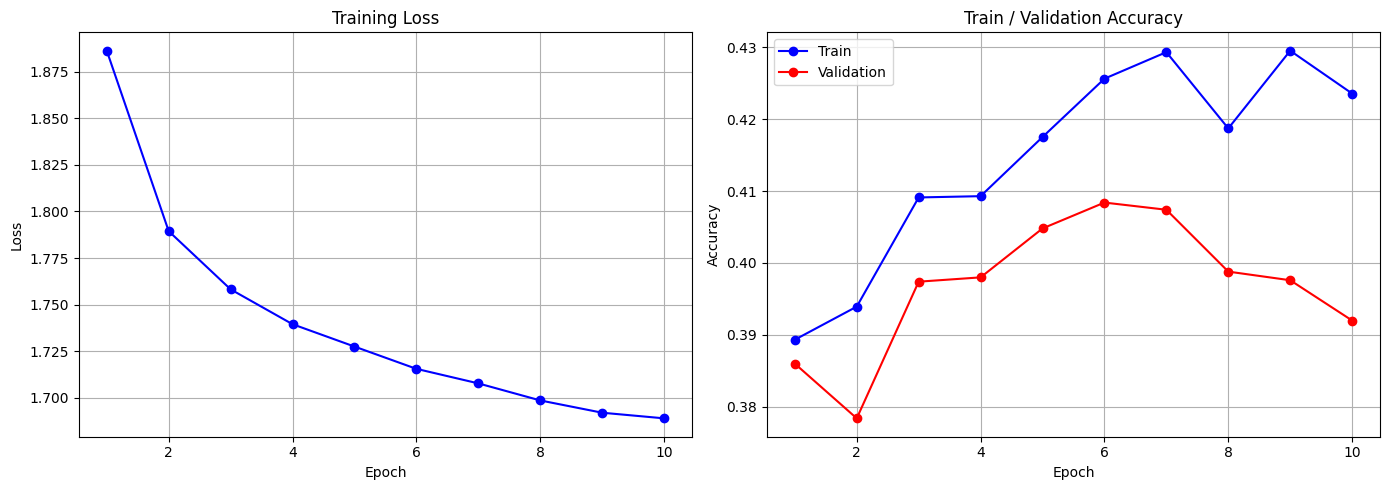

In [16]:
# 학습 과정 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, num_epochs+1), loss_history, 'b-o')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.grid(True)

ax2.plot(range(1, num_epochs+1), train_acc_history, 'b-o', label='Train')
ax2.plot(range(1, num_epochs+1), val_acc_history, 'r-o', label='Validation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Train / Validation Accuracy'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## 6. 학습 결과 평가

### Confusion Matrix
어떤 클래스를 잘 맞추고, 어떤 클래스를 혼동하는지 한눈에 파악할 수 있습니다.

> **참고**: 평가 지표(metrics)를 편리하게 계산할 수 있는 **[torchmetrics](https://lightning.ai/docs/torchmetrics/)** 라이브러리도 있습니다.
> Accuracy, F1, AUROC 등 다양한 지표를 GPU 위에서 직접 계산할 수 있습니다.

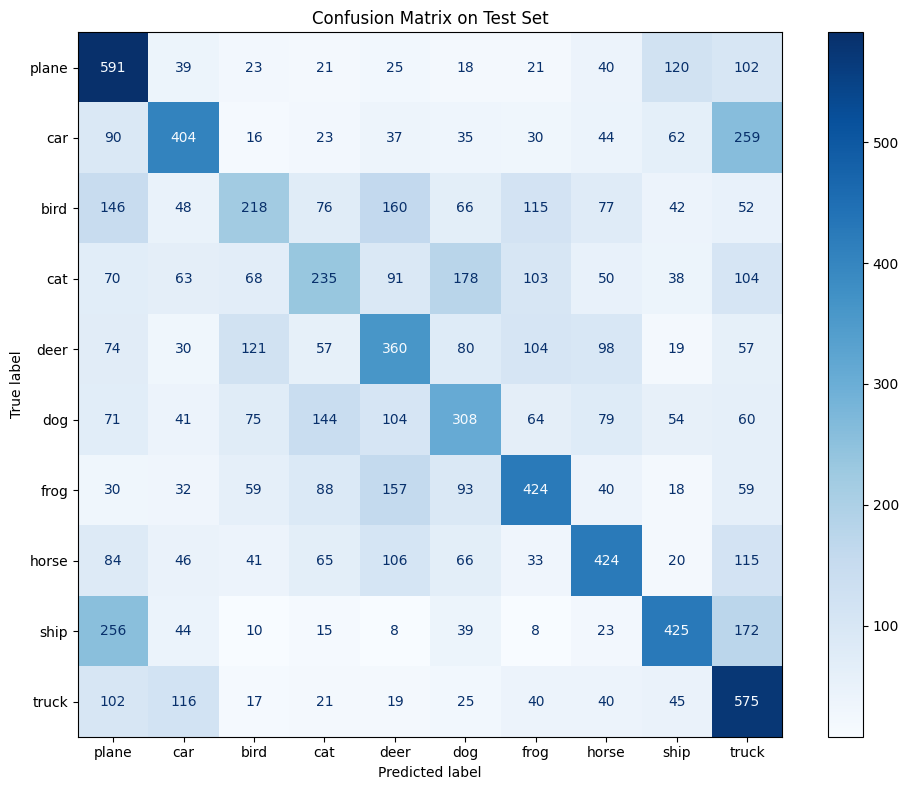


Test Accuracy: 0.3964


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        ####################################################################
        # TODO 4: 예측값을 계산하세요 (~3줄)                                   #
        # 1) 모델에 images를 입력하여 outputs 계산                             #
        # 2) outputs에서 가장 큰 값의 인덱스를 predicted로 저장                   #
        # 3) predicted와 labels를 각각 리스트에 추가                           #
        ####################################################################
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        ####################################################################
        #                         END OF YOUR CODE                         #
        ####################################################################

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()

test_acc = sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f'\nTest Accuracy: {test_acc:.4f}')

## 7. (Bonus) Learning Rate에 따른 결과 비교

Learning Rate(학습률)는 모델 학습에서 가장 중요한 하이퍼파라미터 중 하나입니다.
- **너무 크면**: loss가 발산하여 학습이 불안정해집니다
- **적절하면**: loss가 안정적으로 감소합니다
- **너무 작으면**: 수렴이 매우 느려집니다

> 더 극적인 차이를 보기 위해 SGD + Momentum을 사용하고, LR 범위를 넓게 설정합니다.

LR=1.0    → Final Loss: 101.0144, Val Acc: 0.2960
LR=0.1    → Final Loss: 9.9484, Val Acc: 0.2746
LR=0.01   → Final Loss: 1.8395, Val Acc: 0.3334
LR=0.001  → Final Loss: 1.6598, Val Acc: 0.3986


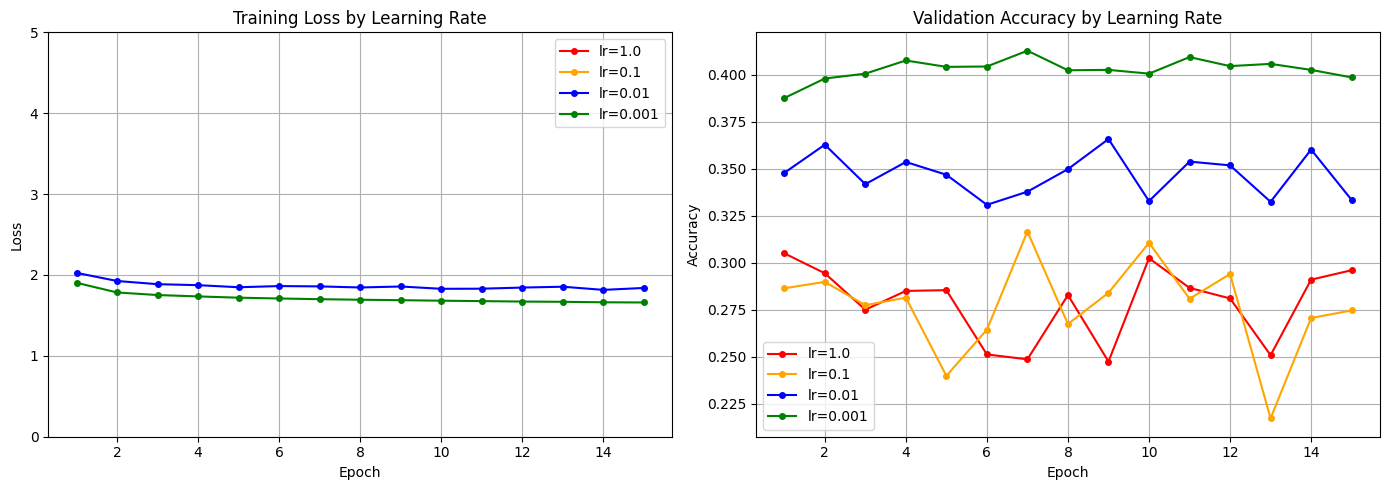

In [18]:
# 다양한 Learning Rate로 학습 비교 (SGD + Momentum)
learning_rates = [1.0, 0.1, 0.01, 0.001]
colors = ['red', 'orange', 'blue', 'green']
all_results = {}

for lr in learning_rates:
    model_lr = LinearClassifier().to(device)
    optimizer_lr = optim.SGD(model_lr.parameters(), lr=lr, momentum=0.9)
    loss_hist, val_hist = [], []

    for epoch in range(15):
        model_lr.train()
        epoch_loss, num_batches = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer_lr.zero_grad()
            loss = criterion(model_lr(images), labels)
            loss.backward()
            optimizer_lr.step()
            epoch_loss += loss.item()
            num_batches += 1
        loss_hist.append(epoch_loss / num_batches)
        val_hist.append(evaluate(model_lr, val_loader, device))

    all_results[lr] = {'loss': loss_hist, 'val_acc': val_hist}
    print(f'LR={lr:<6} → Final Loss: {loss_hist[-1]:.4f}, Val Acc: {val_hist[-1]:.4f}')

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for (lr, data), c in zip(all_results.items(), colors):
    ax1.plot(range(1, 16), data['loss'], '-o', color=c, label=f'lr={lr}', markersize=4)
    ax2.plot(range(1, 16), data['val_acc'], '-o', color=c, label=f'lr={lr}', markersize=4)

ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss by Learning Rate'); ax1.legend(); ax1.grid(True)
ax1.set_ylim(bottom=0, top=5)

ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy by Learning Rate'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()